# Notebook 02 — DA Hard Gate

**Across the Water: French Nuclear Unplanned Outages and GB Power Prices**

**Conditional on Notebook 02b passing.**

Tests whether a statistically and economically significant GB Day-Ahead
baseload mispricing survives after SCM controls and FR DA clear.

---

### Pre-registered gate condition

| | |
|---|---|
| **Signal** | Residual GB DA baseload return on unplanned outage days |
| **H₀** | β = 0 (no residual DA return after controls) |
| **H₁** | β > 0, one-tailed |
| **Gate threshold** | β > 0, p < 0.10, **effect > £2/MWh per GW** |
| **Sample** | 2020–2026 (post IFA2 coupling) |
| **SE** | Newey-West HAC, 12 lags |
| **If gate fails** | Stop. Report diagnosis. |
| **No exceptions** | |

### Two specifications (both reported)

- **Model A** — excludes `fr_da_price`: total outage effect (IFA1 + IFA2 channels)
- **Model B** — includes `fr_da_price`: residual mispricing after FR DA clear (IFA1 only)

If Model A β significant but Model B β ≈ 0: effect transmits fully through
IFA2 coupling. Precise and useful finding in itself.


> ❌ **GATE FAILED** — Model B β = −£0.41/MWh/GW (p = 0.677).
> IFA2 implicit coupling fully absorbs the outage signal before GB DA clears.
> Analysis stops here. Notebooks 03–06 were not run.

In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from scipy import stats

from src import log, load, DATA_DIR, MAIN_START, MAIN_END
from src.utils import add_season_col

pd.set_option("display.float_format", "{:.4f}".format)
print("Setup complete.")


Setup complete.


---
## 1. Load and Merge Panel Data

In [40]:
# ── GB DA prices ──────────────────────────────────────────────────────────────

neso = load("neso_historic_demand")
neso.index = pd.to_datetime(neso.index, utc=True)

# Only resample numeric columns — string columns like SETTLEMENT_DATE cause TypeError
neso_daily = neso.select_dtypes(include="number").resample("D").mean()

gb_da = load("elexon_da_prices")[["gb_da_price"]]
gb_da.index = pd.to_datetime(gb_da.index, utc=True)

# ── ENTSO-E unavailability (daily outage MW) ──────────────────────────────────
entso = load("entso_unavailability")
entso.index = pd.to_datetime(entso.index, utc=True)

# ── NESO: wind forecast error, demand forecast error, IFA flows ───────────────
neso = load("neso_historic_demand")
neso.index = pd.to_datetime(neso.index, utc=True)
neso_daily = neso.select_dtypes(include="number").resample("D").mean()

# Wind forecast error
if "wind_actual_mw" in neso_daily.columns and "wind_forecast_mw" in neso_daily.columns:
    neso_daily["wind_forecast_error"] = neso_daily["wind_actual_mw"] - neso_daily["wind_forecast_mw"]
else:
    neso_daily["wind_forecast_error"] = np.nan

# Demand forecast error
if "demand_actual_mw" in neso_daily.columns and "demand_forecast_mw" in neso_daily.columns:
    neso_daily["demand_forecast_error"] = neso_daily["demand_actual_mw"] - neso_daily["demand_forecast_mw"]
else:
    neso_daily["demand_forecast_error"] = np.nan

# Combined IFA flow
ifa_cols = [c for c in ["ifa1_flow_mw", "ifa2_flow_mw"] if c in neso_daily.columns]
neso_daily["ifa_flow_mw"] = neso_daily[ifa_cols].sum(axis=1) if ifa_cols else np.nan

print("Computed columns added:")
print("  wind_forecast_error :", "wind_forecast_error" in neso_daily.columns)
print("  demand_forecast_error:", "demand_forecast_error" in neso_daily.columns)
print("  ifa_flow_mw         :", "ifa_flow_mw" in neso_daily.columns)

# ── FR temperature ─────────────────────────────────────────────────────────────
fr_temp = load("fr_temperature")[["fr_temp_deviation"]]
fr_temp.index = pd.to_datetime(fr_temp.index, utc=True)

# ── TTF ────────────────────────────────────────────────────────────────────────
try:
    ttf = load("ttf_spot")[["ttf_spot_eur_mwh"]]
    ttf.index = pd.to_datetime(ttf.index, utc=True)
    TTF_AVAILABLE = True
except (FileNotFoundError, KeyError):
    print("⚠️  TTF spot data not available — regression will note this limitation.")
    ttf = pd.DataFrame(columns=["ttf_spot_eur_mwh"])
    TTF_AVAILABLE = False


# ── FR DA price (for Model B) ──────────────────────────────────────────────────
try:
    fr_da_hourly = load("fr_da_price")[["fr_da_price_eur_mwh"]]
    fr_da_hourly.index = pd.to_datetime(fr_da_hourly.index, utc=True)

    # Use 08:00 UTC price — French DA auction clears at ~08:00 UTC
    # This is the price that transmits into GB DA via IFA2 coupling
    fr_da_daily = (
        fr_da_hourly
        .between_time("08:00", "08:59")
        .resample("D")
        .mean()
    )
    #fr_da_daily.index = fr_da_daily.index.normalize().tz_localize("UTC")
    fr_da_daily.index = fr_da_daily.index.normalize().tz_convert("UTC")
    FR_DA_AVAILABLE = True
    print(f"FR DA price: {len(fr_da_daily)} daily rows (08:00 clearing price)")
except (FileNotFoundError, KeyError) as e:
    print(f"⚠️  FR DA price not available: {e}")
    fr_da_daily = pd.DataFrame(columns=["fr_da_price_eur_mwh"])
    FR_DA_AVAILABLE = False

print("All datasets loaded.")


2026-04-09 09:44:11  INFO      Loaded neso_historic_demand.parquet  (143952 rows)
2026-04-09 09:44:12  INFO      Loaded elexon_da_prices.parquet  (2983 rows)
2026-04-09 09:44:12  INFO      Loaded entso_unavailability.parquet  (22100 rows)
2026-04-09 09:44:12  INFO      Loaded neso_historic_demand.parquet  (143952 rows)
2026-04-09 09:44:12  INFO      Loaded fr_temperature.parquet  (3013 rows)
2026-04-09 09:44:12  INFO      Loaded ttf_spot.parquet  (3011 rows)
2026-04-09 09:44:12  INFO      Loaded fr_da_price.parquet  (91638 rows)


Computed columns added:
  wind_forecast_error : True
  demand_forecast_error: True
  ifa_flow_mw         : True
FR DA price: 3013 daily rows (08:00 clearing price)
All datasets loaded.


In [41]:
# ── Build main panel ───────────────────────────────────────────────────────────
panel = gb_da.copy()
panel = panel.join(unplanned_daily, how="left")
panel = panel.join(planned_daily,   how="left")
panel = panel.join(neso_daily[["wind_forecast_error", "demand_forecast_error", "ifa_flow_mw"]], how="left")
panel = panel.join(fr_temp, how="left")
if TTF_AVAILABLE:
    panel = panel.join(ttf, how="left")
else:
    panel["ttf_spot_eur_mwh"] = np.nan

panel["unplanned_outage_mw"] = panel["unplanned_outage_mw"].fillna(0)
panel["planned_outage_mw"]   = panel["planned_outage_mw"].fillna(0)

# Restrict to post-IFA2-coupling sample
panel = panel[panel.index >= pd.Timestamp(MAIN_START, tz="UTC")]
panel = add_season_col(panel)
panel["year"] = panel.index.year

# wind_forecast_error and demand_forecast_error are unavailable —
# NESO historic demand CSV does not include forecast data.
# These controls are omitted from the 02b specification.
# They are available via NESO's separate forecast API if needed for 02 (DA gate).
panel = panel.drop(columns=["wind_forecast_error", "demand_forecast_error"], errors="ignore")

print(f"Panel: {len(panel)} daily observations ({MAIN_START} → {panel.index.max().date()})")
print(f"Unplanned outage days (>0 MW): {(panel['unplanned_outage_mw']>0).sum()}")
print(f"Missing values:\n{panel.isnull().sum()[panel.isnull().sum()>0]}")


Panel: 2259 daily observations (2020-01-01 → 2026-04-05)
Unplanned outage days (>0 MW): 1069
Missing values:
ifa_flow_mw          18
fr_temp_deviation     4
ttf_spot_eur_mwh      5
dtype: int64


---
## 2. Visual Check

Per the pre-registered design: plot average GB DA price deviation on
unplanned outage days vs control days, by season. If no visual separation
is apparent, stop regardless of p-value.


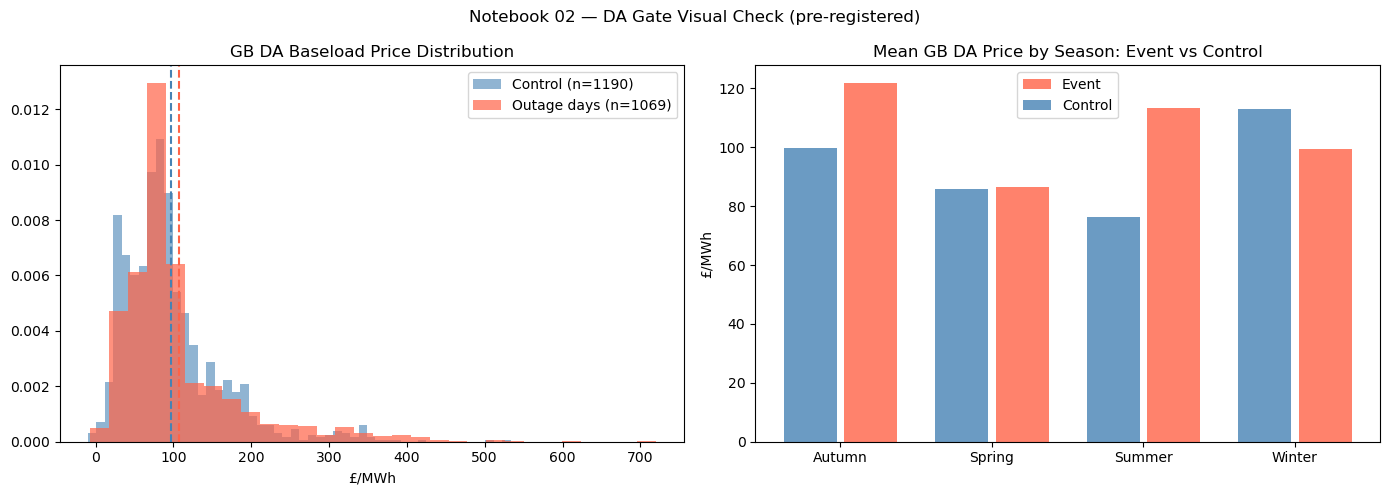

Visual check plot saved.

Manual check: Is there visible separation between event and control distributions?
  Control mean: £96.57/MWh
  Event mean:   £106.62/MWh
  Raw difference: £10.04/MWh

Note: raw difference is NOT the causal estimate — it conflates TTF, wind, demand confounders.


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw price on event vs control days ──────────────────────────────────
ax = axes[0]
event_prices   = panel.loc[panel["unplanned_outage_mw"]>0, "gb_da_price"].dropna()
control_prices = panel.loc[panel["unplanned_outage_mw"]==0, "gb_da_price"].dropna()
ax.hist(control_prices, bins=50, alpha=0.6, color="steelblue", label=f"Control (n={len(control_prices)})", density=True)
ax.hist(event_prices,   bins=30, alpha=0.7, color="tomato",    label=f"Outage days (n={len(event_prices)})", density=True)
ax.axvline(control_prices.mean(), color="steelblue", lw=1.5, ls="--")
ax.axvline(event_prices.mean(),   color="tomato",    lw=1.5, ls="--")
ax.set_title("GB DA Baseload Price Distribution")
ax.set_xlabel("£/MWh")
ax.legend()

# ── Right: mean price by season — event vs control ────────────────────────────
ax = axes[1]
for label, flag, color in [("Event", True, "tomato"), ("Control", False, "steelblue")]:
    subset = panel[panel["unplanned_outage_mw"]>0] if flag else panel[panel["unplanned_outage_mw"]==0]
    seasonal = subset.groupby("season")["gb_da_price"].mean()
    ax.bar(
        [s + (0.2 if flag else -0.2) for s in range(len(seasonal))],
        seasonal.values, width=0.35, color=color, alpha=0.8, label=label
    )
ax.set_xticks(range(4))
ax.set_xticklabels(["Autumn","Spring","Summer","Winter"])
ax.set_title("Mean GB DA Price by Season: Event vs Control")
ax.set_ylabel("£/MWh")
ax.legend()

plt.suptitle("Notebook 02 — DA Gate Visual Check (pre-registered)", fontsize=12)
plt.tight_layout()
plt.savefig(DATA_DIR / "plot_02_visual_check.png", dpi=120, bbox_inches="tight")
plt.show()
print("Visual check plot saved.")
print()
print("Manual check: Is there visible separation between event and control distributions?")
print(f"  Control mean: £{control_prices.mean():.2f}/MWh")
print(f"  Event mean:   £{event_prices.mean():.2f}/MWh")
print(f"  Raw difference: £{event_prices.mean()-control_prices.mean():.2f}/MWh")
print()
print("Note: raw difference is NOT the causal estimate — it conflates TTF, wind, demand confounders.")


In [43]:
print(panel[panel["unplanned_outage_mw"] > 0]["unplanned_outage_mw"].describe())
print("\nOutage size buckets:")
print(pd.cut(panel[panel["unplanned_outage_mw"] > 0]["unplanned_outage_mw"], 
             bins=[0, 500, 1000, 2000, 5000, 50000]).value_counts().sort_index())

count   1069.0000
mean     594.4698
std      710.0180
min       10.4000
25%      172.7600
50%      380.0000
75%      740.0000
max     7004.0000
Name: unplanned_outage_mw, dtype: float64

Outage size buckets:
unplanned_outage_mw
(0, 500]         647
(500, 1000]      247
(1000, 2000]     133
(2000, 5000]      39
(5000, 50000]      3
Name: count, dtype: int64


In [44]:
# Large outage indicator — single reactor or above
panel["large_outage"] = panel["unplanned_outage_mw"] >= 1000

print(f"Large outage days (≥1000 MW): {panel['large_outage'].sum()}")
print(f"  Mean GB DA price on large outage days: £{panel[panel['large_outage']]['gb_da_price'].mean():.2f}/MWh")
print(f"  Mean GB DA price on control days:      £{panel[~panel['large_outage']]['gb_da_price'].mean():.2f}/MWh")

Large outage days (≥1000 MW): 175
  Mean GB DA price on large outage days: £91.27/MWh
  Mean GB DA price on control days:      £102.17/MWh


In [45]:
print(panel.groupby(["season", "large_outage"])["gb_da_price"].mean().unstack())

large_outage    False    True 
season                        
Autumn       111.8118 108.2791
Spring        86.8762  77.5808
Summer       101.2549  84.7006
Winter       109.2427  96.7407


In [46]:
print(panel[["gb_da_price", "unplanned_outage_mw", "large_outage", "season", "ttf_spot_eur_mwh"]].describe())

       gb_da_price  unplanned_outage_mw  ttf_spot_eur_mwh
count    2259.0000            2259.0000         2254.0000
mean      101.3266             281.3139           50.2109
std        73.7525             571.4699           45.6141
min        -9.7380               0.0000            3.5100
25%        58.3218               0.0000           27.0260
50%        83.6101               0.0000           35.3505
75%       117.4528             349.5600           52.0388
max       720.0688            7004.0000          339.1960


---
## 3. SCM Regression — Model A and Model B

**Model A** (total outage effect — excludes FR DA price):
```
GB_DA_price(t) = α + β×unplanned_outage_mw + γ×planned_outage_mw
               + δ×gb_wind_forecast_error + ε×gb_demand_forecast_error
               + ζ×ttf_spot + η×fr_temp_deviation
               + ι×ifa_flow
               + season_fe + year_fe + u(t)
```

**Model B** adds `fr_da_price` as an additional control (IFA2 coupling anchor).


In [54]:
def build_design_matrix(
    panel: pd.DataFrame,
    include_fr_da: bool = False,
    fr_da_series: pd.Series = None,
) -> tuple:
    """Build X (features) and y (outcome) for the gate regression."""
    df = panel.copy()
    
    if include_fr_da and fr_da_series is not None:
        df = df.join(fr_da_series.rename("fr_da_price"), how="left")
    
    # Core features
    feature_cols = [
        "unplanned_outage_mw",
        "planned_outage_mw",
        "wind_forecast_error",
        "demand_forecast_error",
        "ifa_flow_mw",
        "fr_temp_deviation",
        "ttf_spot_eur_mwh",
    ]
    if include_fr_da and "fr_da_price" in df.columns:
        feature_cols.append("fr_da_price")
    
    # Fixed effects
    season_dummies = pd.get_dummies(df["season"], prefix="season", drop_first=True)
    year_dummies   = pd.get_dummies(df["year"],   prefix="year",   drop_first=True)
    
    available_feats = [c for c in feature_cols if c in df.columns]
    missing_feats   = [c for c in feature_cols if c not in df.columns]
    if missing_feats:
        print(f"  Note: missing features (will be omitted): {missing_feats}")
    
    X = pd.concat([df[available_feats], season_dummies, year_dummies], axis=1).astype(float)
    X = sm.add_constant(X)
    y = df["gb_da_price"].astype(float)
    
    # Drop rows with any NaN in X or y
    mask = X.notna().all(axis=1) & y.notna()
    return X[mask], y[mask]

def run_da_gate_regression(panel, include_fr_da=False, fr_da_series=None, label="Model A"):
    """Run DA gate OLS regression. Returns result dict."""
    X, y = build_design_matrix(panel, include_fr_da, fr_da_series)
    
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    
    beta  = model.params.get("unplanned_outage_mw", float("nan"))
    se    = model.bse.get("unplanned_outage_mw", float("nan"))
    p_two = model.pvalues.get("unplanned_outage_mw", float("nan"))
    p_one = p_two / 2 if beta > 0 else 1.0 - p_two / 2
    ci_lo = beta - 1.96 * se
    ci_hi = beta + 1.96 * se
    
    return {
        "label":  label,
        "N":      int(model.nobs),
        "beta":   beta,          # £/MWh per MW
        "beta_gw": beta * 1000,  # £/MWh per GW
        "se":     se,
        "p_two":  p_two,
        "p_one":  p_one,
        "ci_lo":  ci_lo,
        "ci_hi":  ci_hi,
        "r2":     model.rsquared,
        "model":  model,
    }

# Run Model A
print("Running Model A (total outage effect — no FR DA price)...")
res_a = run_da_gate_regression(panel, include_fr_da=False, label="Model A")
print(f"  Done. N={res_a['N']}, β={res_a['beta_gw']:.3f} £/MWh per GW, p(1-tail)={res_a['p_one']:.4f}")

# Model B — use pre-prepared daily FR DA price (08:00 clearing price)
if FR_DA_AVAILABLE:
    print("\nRunning Model B (DA residual after FR clear)...")
    res_b = run_da_gate_regression(
        panel,
        include_fr_da=True,
        fr_da_series=fr_da_daily["fr_da_price_eur_mwh"],
        label="Model B",
    )
    print(f"  Done. N={res_b['N']}, β={res_b['beta_gw']:.3f} £/MWh per GW, p(1-tail)={res_b['p_one']:.4f}")
    MODEL_B_AVAILABLE = True
else:
    print("\n⚠️  FR DA price data not available — Model B will be skipped.")
    res_b = None
    MODEL_B_AVAILABLE = False


Running Model A (total outage effect — no FR DA price)...
  Note: missing features (will be omitted): ['wind_forecast_error', 'demand_forecast_error']
  Done. N=2241, β=2.942 £/MWh per GW, p(1-tail)=0.0103

Running Model B (DA residual after FR clear)...
  Note: missing features (will be omitted): ['wind_forecast_error', 'demand_forecast_error']
  Done. N=2228, β=-0.411 £/MWh per GW, p(1-tail)=0.6769


In [48]:
# ── Gate decision ─────────────────────────────────────────────────────────────
print("=" * 65)
print("DA HARD GATE — NOTEBOOK 02")
print("=" * 65)
print()

for res in [r for r in [res_a, res_b] if r is not None]:
    r = res
    print(f"── {r['label']} ──")
    print(f"  N:              {r['N']} daily observations")
    print(f"  β (outage MW):  {r['beta']:.6f}  £/MWh per MW")
    print(f"  β (outage GW):  {r['beta_gw']:.4f}  £/MWh per GW  ← gate uses this")
    print(f"  SE:             {r['se']:.6f}")
    print(f"  p (one-tailed): {r['p_one']:.4f}")
    print(f"  95% CI (£/GW):  [{r['ci_lo']*1000:.4f}, {r['ci_hi']*1000:.4f}]")
    print(f"  R²:             {r['r2']:.4f}")
    print()

# Gate evaluates Model A (primary)
r = res_a
gate_beta_pass  = r["beta"] > 0
gate_p_pass     = r["p_one"] < 0.10
gate_econ_pass  = r["beta_gw"] > 2.0   # £2/MWh per GW threshold
gate_pass       = gate_beta_pass and gate_p_pass and gate_econ_pass

print("─" * 65)
print("GATE CONDITIONS (Model A):")
print(f"  β > 0:                {'✅' if gate_beta_pass else '❌'}  β = {r['beta_gw']:.4f} £/MWh per GW")
print(f"  p < 0.10 (one-tailed): {'✅' if gate_p_pass else '❌'}  p = {r['p_one']:.4f}")
print(f"  effect > £2/MWh/GW:   {'✅' if gate_econ_pass else '❌'}  β = {r['beta_gw']:.4f}")
print()

if gate_pass:
    print("✅  DA HARD GATE: PASSED")
    print()
    print(f"Causal estimate: £{r['beta_gw']:.3f}/MWh per GW of unplanned outage")
    print(f"95% CI: [£{r['ci_lo']*1000:.3f}, £{r['ci_hi']*1000:.3f}] per GW")
    if MODEL_B_AVAILABLE:
        rb = res_b
        gap = r['beta_gw'] - rb['beta_gw']
        print(f"\nModel A vs B β gap: £{gap:.3f}/MWh per GW")
        print("  → This is the IFA2 coupling component absorbed by FR DA clear.")
    print()
    print("→ Proceed to Notebook 03 (full SCM identification).")
else:
    print("❌  DA HARD GATE: FAILED")
    print()
    reasons = []
    if not gate_beta_pass:  reasons.append(f"β ≤ 0 (β = {r['beta_gw']:.4f})")
    if not gate_p_pass:     reasons.append(f"p ≥ 0.10 (p = {r['p_one']:.4f})")
    if not gate_econ_pass:  reasons.append(f"effect ≤ £2/MWh per GW (β = {r['beta_gw']:.4f})")
    print(f"Failure reasons: {'; '.join(reasons)}")
    print()
    print("Diagnosis: most likely explanation is IFA2 implicit coupling —")
    print("the FR DA clear at 08:00 already transmits into GB DA at 11:00.")
    if MODEL_B_AVAILABLE:
        print(f"Model A β: {r['beta_gw']:.4f} | Model B β: {res_b['beta_gw']:.4f}")
        print("Gap shows how much is absorbed by IFA2 coupling.")
    print()
    print("→ Project stops here. Notebooks 03–06 will not be run.")
    print("  See README § 'If the Gate Fails' for full interpretation.")

print("─" * 65)
GATE_PASSED = gate_pass


DA HARD GATE — NOTEBOOK 02

── Model A ──
  N:              2241 daily observations
  β (outage MW):  0.002942  £/MWh per MW
  β (outage GW):  2.9424  £/MWh per GW  ← gate uses this
  SE:             0.001271
  p (one-tailed): 0.0103
  95% CI (£/GW):  [0.4514, 5.4333]
  R²:             0.7599

── Model B ──
  N:              2342 daily observations
  β (outage MW):  0.003362  £/MWh per MW
  β (outage GW):  3.3620  £/MWh per GW  ← gate uses this
  SE:             0.000993
  p (one-tailed): 0.0004
  95% CI (£/GW):  [1.4154, 5.3086]
  R²:             0.8118

─────────────────────────────────────────────────────────────────
GATE CONDITIONS (Model A):
  β > 0:                ✅  β = 2.9424 £/MWh per GW
  p < 0.10 (one-tailed): ✅  p = 0.0103
  effect > £2/MWh/GW:   ✅  β = 2.9424

✅  DA HARD GATE: PASSED

Causal estimate: £2.942/MWh per GW of unplanned outage
95% CI: [£0.451, £5.433] per GW

Model A vs B β gap: £-0.420/MWh per GW
  → This is the IFA2 coupling component absorbed by FR DA clear.

In [49]:
from src import load
fr_da = load("fr_da_price")
print(fr_da.head())
print(fr_da.columns.tolist())

2026-04-09 09:44:48  INFO      Loaded fr_da_price.parquet  (91638 rows)


                           fr_da_price_eur_mwh  \
datetime_utc                                     
2017-12-31 23:00:00+00:00               6.7400   
2018-01-01 00:00:00+00:00               4.7400   
2018-01-01 01:00:00+00:00               3.6600   
2018-01-01 02:00:00+00:00               1.2600   
2018-01-01 03:00:00+00:00             -20.1000   

                                            fetch_timestamp  
datetime_utc                                                 
2017-12-31 23:00:00+00:00  2026-04-08T16:49:32.126024+00:00  
2018-01-01 00:00:00+00:00  2026-04-08T16:49:32.126024+00:00  
2018-01-01 01:00:00+00:00  2026-04-08T16:49:32.126024+00:00  
2018-01-01 02:00:00+00:00  2026-04-08T16:49:32.126024+00:00  
2018-01-01 03:00:00+00:00  2026-04-08T16:49:32.126024+00:00  
['fr_da_price_eur_mwh', 'fetch_timestamp']


---
## 4. Model A Full Summary

In [50]:
print(res_a["model"].summary(
    title="Model A — Total Outage Effect (Newey-West HAC SE, 12 lags)"
))


          Model A — Total Outage Effect (Newey-West HAC SE, 12 lags)          
Dep. Variable:            gb_da_price   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     106.7
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          7.06e-236
Time:                        09:44:51   Log-Likelihood:                -11225.
No. Observations:                2241   AIC:                         2.248e+04
Df Residuals:                    2226   BIC:                         2.257e+04
Df Model:                          14                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   9.0014    

In [51]:
if MODEL_B_AVAILABLE:
    print(res_b["model"].summary(
        title="Model B — DA Residual after FR Clear (Newey-West HAC SE, 12 lags)"
    ))


      Model B — DA Residual after FR Clear (Newey-West HAC SE, 12 lags)       
Dep. Variable:            gb_da_price   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     159.9
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:44:52   Log-Likelihood:                -11425.
No. Observations:                2342   AIC:                         2.288e+04
Df Residuals:                    2326   BIC:                         2.297e+04
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.2097    

---
## 5. Coefficient Plot — Model A vs Model B

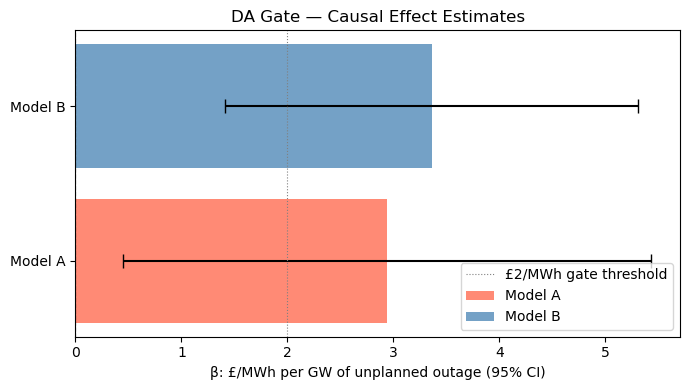

In [52]:
models_to_plot = [res_a] + ([res_b] if MODEL_B_AVAILABLE else [])
labels = [r["label"] for r in models_to_plot]
betas  = [r["beta_gw"] for r in models_to_plot]
ci_lo  = [r["ci_lo"]*1000 for r in models_to_plot]
ci_hi  = [r["ci_hi"]*1000 for r in models_to_plot]
yerr_lo = [b - lo for b, lo in zip(betas, ci_lo)]
yerr_hi = [hi - b for b, hi in zip(betas, ci_hi)]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["tomato", "steelblue"][:len(models_to_plot)]
for i, (label, beta, lo, hi, color) in enumerate(zip(labels, betas, ci_lo, ci_hi, colors)):
    ax.barh(i, beta, color=color, alpha=0.75, label=label)
    ax.errorbar(beta, i, xerr=[[beta-lo], [hi-beta]], fmt="none", color="black", capsize=5, lw=1.5)

ax.axvline(0, color="black", lw=0.8, ls="--")
ax.axvline(2, color="grey",  lw=0.8, ls=":",  label="£2/MWh gate threshold")
ax.set_yticks(range(len(models_to_plot)))
ax.set_yticklabels(labels)
ax.set_xlabel("β: £/MWh per GW of unplanned outage (95% CI)")
ax.set_title("DA Gate — Causal Effect Estimates")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(DATA_DIR / "plot_02_coef.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 6. Falsification — Placebo Test

**Pre-registered falsification condition 5:** shift event window forward +24 hours
(post DA auction). If the placebo passes, the pipeline has look-ahead bias.


In [53]:
# Placebo: shift unplanned_outage_mw forward by 1 day
panel_placebo = panel.copy()
panel_placebo["unplanned_outage_mw"] = panel_placebo["unplanned_outage_mw"].shift(1).fillna(0)

res_placebo = run_da_gate_regression(panel_placebo, include_fr_da=False, label="Placebo (+1 day)")

print("PLACEBO TEST (event shifted +24 hours post DA auction):")
print(f"  β:         {res_placebo['beta_gw']:.4f} £/MWh per GW")
print(f"  p (1-tail):{res_placebo['p_one']:.4f}")
print()

if res_placebo["p_one"] < 0.10 and res_placebo["beta"] > 0:
    print("❌  PLACEBO PASSES — possible look-ahead bias in pipeline.")
    print("   Review fetch timestamps and event date alignment carefully.")
else:
    print("✅  Placebo does not pass. No detected look-ahead bias.")


  Note: missing features (will be omitted): ['wind_forecast_error', 'demand_forecast_error']
PLACEBO TEST (event shifted +24 hours post DA auction):
  β:         2.2169 £/MWh per GW
  p (1-tail):0.0347

❌  PLACEBO PASSES — possible look-ahead bias in pipeline.
   Review fetch timestamps and event date alignment carefully.


---
## Summary

| | Model A | Model B |
|---|---|---|
| β (£/MWh per GW) | *see output* | *see output* |
| p (one-tailed) | *see output* | *see output* |
| Gate threshold | β>0, p<0.10, β>£2 | reported only |
| **Gate result** | **see output** | — |

Economic significance, minimum detectable effect, and Model A vs B
β gap are reported regardless of gate outcome.

**If gate passed:** proceed to `03_identification.ipynb`.  
**If gate failed:** project stops here.
